### check cryosat-2 sarin l2 data

In [ ]:
import numpy as np
import xarray as xr
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from utils.utils import hz01_hz20, dt64_to_dyr


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [40]:
path_cryo2_l2 = 'data/cryosat-2/CS_LTA__SIR_SIN_2__20150508T035141_20150508T035526_E001.nc'
path_namco = 'data/vector/namco_lake.gpkg'


In [41]:
cryo2_l2 = xr.open_dataset(path_cryo2_l2)
lake_gdf = gpd.read_file(path_namco)


In [42]:
cryo2_l2


<xarray.Dataset>
Dimensions:                           (time_cor_01: 257, time_20_ku: 5136)
Coordinates:
    lat_01                            (time_cor_01) float64 ...
    lat_poca_20_ku                    (time_20_ku) float64 ...
    lon_01                            (time_cor_01) float64 ...
    lon_poca_20_ku                    (time_20_ku) float64 ...
  * time_20_ku                        (time_20_ku) datetime64[ns] 2015-05-08T...
  * time_cor_01                       (time_cor_01) datetime64[ns] 2015-05-08...
Data variables: (12/54)
    alt_01                            (time_cor_01) float64 ...
    echo_avg_numval_20_ku             (time_20_ku) float32 ...
    flag_cor_applied_20_ku            (time_20_ku) float64 ...
    flag_cor_err_01                   (time_cor_01) float64 ...
    flag_instr_conf_rx_str_in_use_01  (time_cor_01) float32 ...
    flag_instr_mode_op_20_ku          (time_20_ku) float32 ...
    ...                                ...
    ssha_interp_20_ku                 (time_20_ku) float32 ...
    ssha_interp_numval_20_ku          (time_20_ku) float32 ...
    ssha_interp_rms_20_ku             (time_20_ku) float32 ...
    surf_type_20_ku                   (time_20_ku) float32 ...
    swh_ocean_01_ku                   (time_cor_01) float32 ...
    wind_speed_alt_01_ku              (time_cor_01) float32 ...
Attributes: (12/102)
    product_name:                 CS_LTA__SIR_SIN_2__20150508T035141_20150508...
    processing_stage:             LTA_
    reference_document:           CS-RS-ACS-ESL-5265 2.1
    doi:                          10.5270/CR2-65cff05
    acquisition_station:          Kiruna              
    mission:                      Cryosat
    ...                           ...
    xref_surf_type:               CS_OPER_AUX_LS_MAP_00000000T000000_99999999...
    xref_tidal_load:              CS_OPER_AUX_TDLOAD_00000000T000000_99999999...
    xref_u_wind:                  CS_OPER_AUX_U_WIND_20150508T000000_20150508...
    xref_uso:                     CS_OPER_AUX_DORUSO_20100411T040029_20211117...
    xref_v_wind:                  CS_OPER_AUX_V_WIND_20150508T000000_20150508...
    xref_wet_trop:                CS_OPER_AUX_WETTRP_20150508T000000_20150508...

In [43]:
# select 20Hz points within the lake polygon
pts_20hz = gpd.GeoDataFrame(
  geometry=gpd.points_from_xy(cryo2_l2['lon_poca_20_ku'].values, cryo2_l2['lat_poca_20_ku'].values),
  crs=(lake_gdf.crs or "EPSG:4326")
  )
mask_in_lake = pts_20hz.within(lake_gdf.geometry.union_all()).to_numpy()
cryo2_l2_lake = cryo2_l2.isel(time_20_ku=np.where(mask_in_lake)[0])
cryo2_l2_lake


<xarray.Dataset>
Dimensions:                           (time_cor_01: 257, time_20_ku: 99)
Coordinates:
    lat_01                            (time_cor_01) float64 ...
    lat_poca_20_ku                    (time_20_ku) float64 30.62 30.63 ... 30.89
    lon_01                            (time_cor_01) float64 ...
    lon_poca_20_ku                    (time_20_ku) float64 90.73 90.72 ... 90.69
  * time_20_ku                        (time_20_ku) datetime64[ns] 2015-05-08T...
  * time_cor_01                       (time_cor_01) datetime64[ns] 2015-05-08...
Data variables: (12/54)
    alt_01                            (time_cor_01) float64 ...
    echo_avg_numval_20_ku             (time_20_ku) float32 ...
    flag_cor_applied_20_ku            (time_20_ku) float64 ...
    flag_cor_err_01                   (time_cor_01) float64 ...
    flag_instr_conf_rx_str_in_use_01  (time_cor_01) float32 ...
    flag_instr_mode_op_20_ku          (time_20_ku) float32 ...
    ...                                ...
    ssha_interp_20_ku                 (time_20_ku) float32 ...
    ssha_interp_numval_20_ku          (time_20_ku) float32 ...
    ssha_interp_rms_20_ku             (time_20_ku) float32 ...
    surf_type_20_ku                   (time_20_ku) float32 ...
    swh_ocean_01_ku                   (time_cor_01) float32 ...
    wind_speed_alt_01_ku              (time_cor_01) float32 ...
Attributes: (12/102)
    product_name:                 CS_LTA__SIR_SIN_2__20150508T035141_20150508...
    processing_stage:             LTA_
    reference_document:           CS-RS-ACS-ESL-5265 2.1
    doi:                          10.5270/CR2-65cff05
    acquisition_station:          Kiruna              
    mission:                      Cryosat
    ...                           ...
    xref_surf_type:               CS_OPER_AUX_LS_MAP_00000000T000000_99999999...
    xref_tidal_load:              CS_OPER_AUX_TDLOAD_00000000T000000_99999999...
    xref_u_wind:                  CS_OPER_AUX_U_WIND_20150508T000000_20150508...
    xref_uso:                     CS_OPER_AUX_DORUSO_20100411T040029_20211117...
    xref_v_wind:                  CS_OPER_AUX_V_WIND_20150508T000000_20150508...
    xref_wet_trop:                CS_OPER_AUX_WETTRP_20150508T000000_20150508...

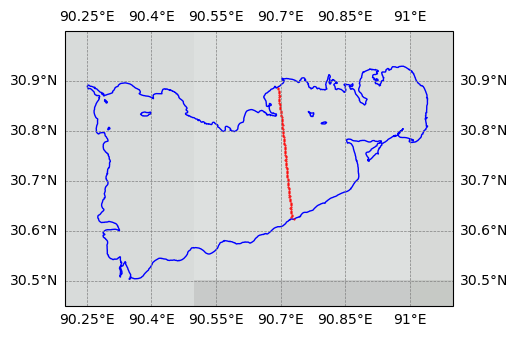

In [44]:
proj = ccrs.PlateCarree(central_longitude=0.0)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection=proj)
ax.set_extent([90.2, 91.1, 30.45, 31], crs=ccrs.PlateCarree())
ax.stock_img()
ax.plot(cryo2_l2_lake['lon_poca_20_ku'][:], cryo2_l2_lake['lat_poca_20_ku'][:], 
                          marker='.', markersize=1, linewidth=0.0, color='red')
lake_gdf.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=1)
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
plt.show()



In [45]:
time_01 = dt64_to_dyr(cryo2_l2_lake['time_cor_01'].values, precision='us')
time_20 = dt64_to_dyr(cryo2_l2_lake['time_20_ku'].values, precision='us')
cryo2_l2_alt_20 = hz01_hz20(data_01hz=cryo2_l2_lake['alt_01'].values, 
                          time_01hz=time_01, 
                          time_20hz=time_20, 
                          interp_method='linear'
                          )


In [46]:
geophy_cor_01hz = cryo2_l2_lake['iono_cor_01'].values + cryo2_l2_lake['load_tide_01'].values + \
                  cryo2_l2_lake['solid_earth_tide_01'].values + cryo2_l2_lake['pole_tide_01'].values + \
                  cryo2_l2_lake['mod_dry_tropo_cor_01'].values + cryo2_l2_lake['mod_wet_tropo_cor_01'].values
geophy_cor_20hz = hz01_hz20(data_01hz=geophy_cor_01hz, 
                            time_01hz=time_01, 
                            time_20hz=time_20, 
                            interp_method='linear'
                            ) 


In [47]:
### geophysical corrected height at 20Hz
ht_20hz_cor = cryo2_l2_alt_20 - cryo2_l2_lake['range_1_20_ku'].values - geophy_cor_20hz


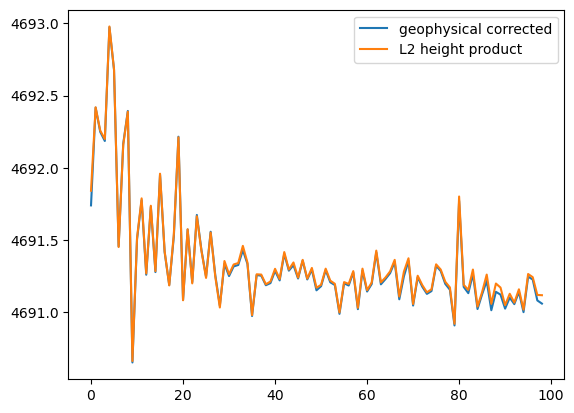

In [48]:
## comparison between geophysical corrected height and L2 height product
plt.plot(ht_20hz_cor, label='geophysical corrected')
plt.plot(cryo2_l2_lake['height_1_20_ku'].values, label='L2 height product')
plt.legend()
